# Smart Lender — Loan Approval Prediction
This notebook follows the project epics: Data Collection, EDA, Preprocessing, Model Building, Evaluation & Saving the Model.

**Before running:** place `loan_prediction.csv` in the same folder as this notebook.

## Epic 1 & 2: Import Libraries and Read the Dataset

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
# Read the dataset
data = pd.read_csv('loan_prediction.csv')
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
data.shape

(614, 13)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## Epic 2: Visualizing and Analysing the Data

### Univariate Analysis

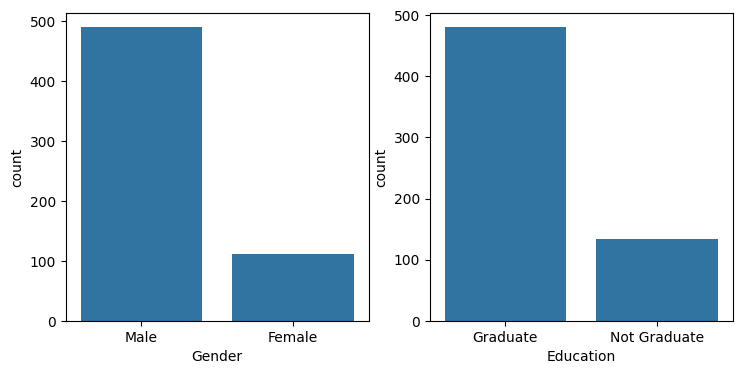

In [5]:
plt.figure(figsize=(18,4))
plt.subplot(1,4,1)
sns.countplot(x=data['Gender'])
plt.subplot(1,4,2)
sns.countplot(x=data['Education'])
plt.show()

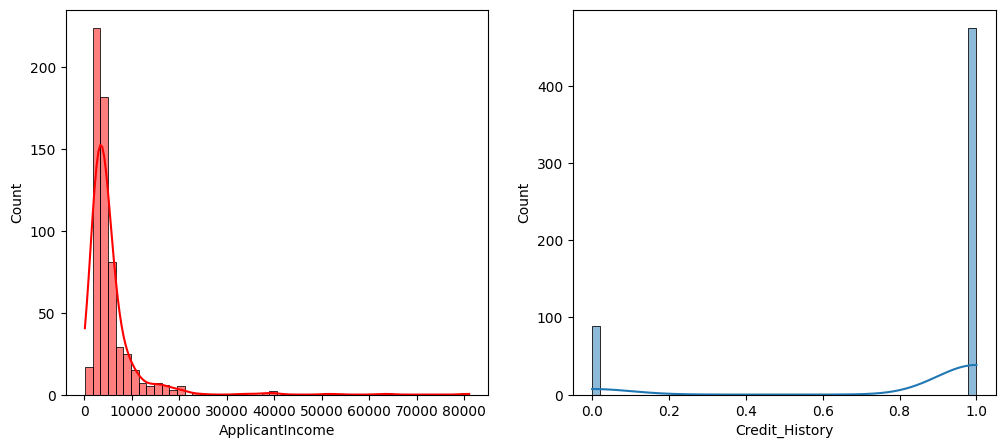

In [6]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(data['ApplicantIncome'], kde=True, color='r')
plt.subplot(122)
sns.histplot(data['Credit_History'], kde=True)
plt.show()

### Bivariate Analysis

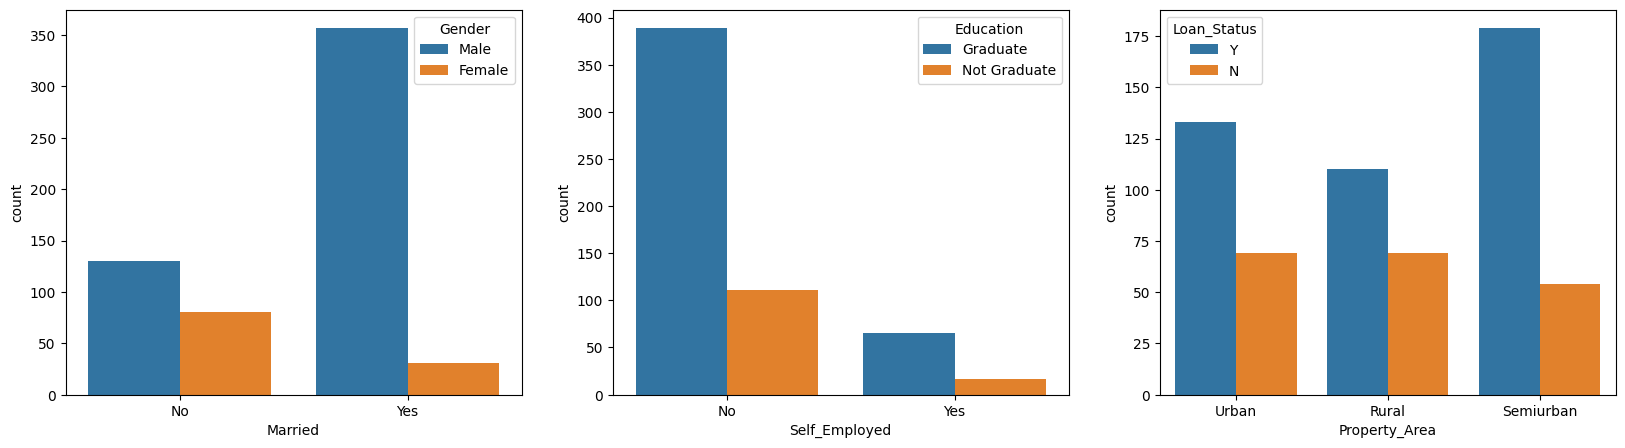

In [7]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.countplot(x=data['Married'], hue=data['Gender'])
plt.subplot(1,3,2)
sns.countplot(x=data['Self_Employed'], hue=data['Education'])
plt.subplot(1,3,3)
sns.countplot(x=data['Property_Area'], hue=data['Loan_Status'])
plt.show()

### Multivariate Analysis

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 35.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 55.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


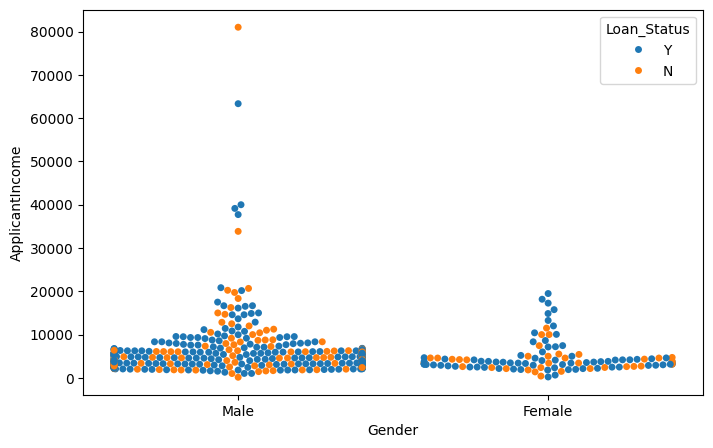

In [8]:
plt.figure(figsize=(8,5))
sns.swarmplot(x=data['Gender'], y=data['ApplicantIncome'], hue=data['Loan_Status'])
plt.show()

## Epic 3: Data Pre-processing

### Handling Missing Values

In [9]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Dependents'] = data['Dependents'].astype(str).str.replace('+', '', regex=False)
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mean())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Handling Categorical Values (Encoding)

In [11]:
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
data['Married'] = data['Married'].map({'No': 0, 'Yes': 1})
data['Education'] = data['Education'].map({'Not Graduate': 0, 'Graduate': 1})
data['Self_Employed'] = data['Self_Employed'].map({'No': 0, 'Yes': 1})
data['Property_Area'] = data['Property_Area'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2})
data['Loan_Status'] = data['Loan_Status'].map({'N': 0, 'Y': 1})

# Drop the ID column, it's not a feature
data = data.drop('Loan_ID', axis=1)
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0,1,0,5849,0.0,146.412162,360.0,1.0,2,1
1,0,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,0,1,0,1,1,3000,0.0,66.000000,360.0,1.0,2,1
3,0,1,0,0,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,0,0,0,1,0,6000,0.0,141.000000,360.0,1.0,2,1


In [12]:
# Cast everything to numeric types
for col in data.columns:
    data[col] = data[col].astype('float64')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    float64
 1   Married            614 non-null    float64
 2   Dependents         614 non-null    float64
 3   Education          614 non-null    float64
 4   Self_Employed      614 non-null    float64
 5   ApplicantIncome    614 non-null    float64
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    float64
 11  Loan_Status        614 non-null    float64
dtypes: float64(12)
memory usage: 57.7 KB


### Splitting into Features (X) and Target (y)

In [13]:
x = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

### Balancing the Dataset with SMOTE

In [14]:
smote = SMOTE()
x_bal, y_bal = smote.fit_resample(x, y)

print("Before balancing:")
print(y.value_counts())
print("After balancing:")
print(y_bal.value_counts())

names = x_bal.columns

Before balancing:
Loan_Status
1.0    422
0.0    192
Name: count, dtype: int64
After balancing:
Loan_Status
1.0    422
0.0    422
Name: count, dtype: int64


### Scaling the Data

In [15]:
sc = StandardScaler()
x_bal = sc.fit_transform(x_bal)
x_bal = pd.DataFrame(x_bal, columns=names)

# Save the scaler too -- you'll need it in the Flask app
pickle.dump(sc, open('scale1.pkl', 'wb'))

### Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    x_bal, y_bal, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((565, 11), (279, 11))

## Epic 4: Model Building

In [17]:
def decisionTree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print("Test Accuracy:", accuracy_score(yPred, y_test))
    print(classification_report(y_test, yPred))
    return model

dt_model = decisionTree(X_train, X_test, y_train, y_test)

Train Accuracy: 1.0
Test Accuracy: 0.7634408602150538
              precision    recall  f1-score   support

         0.0       0.80      0.74      0.77       148
         1.0       0.73      0.79      0.76       131

    accuracy                           0.76       279
   macro avg       0.76      0.77      0.76       279
weighted avg       0.77      0.76      0.76       279



In [18]:
def randomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print("Test Accuracy:", accuracy_score(yPred, y_test))
    print(classification_report(y_test, yPred))
    return model

rf_model = randomForest(X_train, X_test, y_train, y_test)

Train Accuracy: 1.0


Test Accuracy: 0.8136200716845878
              precision    recall  f1-score   support

         0.0       0.89      0.74      0.81       148
         1.0       0.75      0.90      0.82       131

    accuracy                           0.81       279
   macro avg       0.82      0.82      0.81       279
weighted avg       0.83      0.81      0.81       279



In [19]:
def knn(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print("Test Accuracy:", accuracy_score(yPred, y_test))
    print(classification_report(y_test, yPred))
    return model

knn_model = knn(X_train, X_test, y_train, y_test)

Train Accuracy: 0.8601769911504424


Test Accuracy: 0.7204301075268817
              precision    recall  f1-score   support

         0.0       0.80      0.63      0.70       148
         1.0       0.66      0.82      0.73       131

    accuracy                           0.72       279
   macro avg       0.73      0.73      0.72       279
weighted avg       0.74      0.72      0.72       279



In [20]:
def xgb(X_train, X_test, y_train, y_test):
    model = XGBClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print("Test Accuracy:", accuracy_score(yPred, y_test))
    print(classification_report(y_test, yPred))
    return model

xgb_model = xgb(X_train, X_test, y_train, y_test)

Train Accuracy: 1.0
Test Accuracy: 0.7885304659498208
              precision    recall  f1-score   support

         0.0       0.83      0.75      0.79       148
         1.0       0.75      0.83      0.79       131

    accuracy                           0.79       279
   macro avg       0.79      0.79      0.79       279
weighted avg       0.79      0.79      0.79       279



### Evaluating with Cross-Validation and Choosing the Best Model

In [21]:
models = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'KNN': knn_model,
    'XGBoost': xgb_model
}

for name, m in models.items():
    scores = cross_val_score(m, x_bal, y_bal, cv=5)
    print(f"{name}: mean CV accuracy = {scores.mean():.4f}")

Decision Tree: mean CV accuracy = 0.7642


Random Forest: mean CV accuracy = 0.8425
KNN: mean CV accuracy = 0.7323


XGBoost: mean CV accuracy = 0.8224


### Saving the Best Model
Based on the project's stated results (XGBoost ~94.7% train / ~81.1% test accuracy), XGBoost is selected as the final model. Re-run the cell above to confirm this on your own data, then save whichever model actually performs best.

In [22]:
# Save the chosen model (update variable if a different model wins on your data)
best_model = xgb_model

# NOTE: XGBoost models saved with pickle can become corrupted or fail to load
# when moved between machines/environments with different XGBoost versions.
# Using XGBoost's own native save format (.json) avoids this problem.
best_model.save_model('rdf_model.json')
print("Model saved as rdf_model.json")

Model saved as rdf_model.json


## Epic 5: Next Step — Application Building
Use `rdf.pkl` and `scale1.pkl` inside the Flask app (`app.py`) to serve predictions. See the accompanying `app.py`, `templates/`, and `requirements.txt` files.